# **Risk Assessment Framework**

In [1]:
import sys
from pathlib import Path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from src.config import get_path
from src.risk_model import build_risk_registry, risk_heatmap_matrix, strategic_opportunities
from src.viz import apply_project_style, save_figure, plot_risk_matrix

apply_project_style()
tables_dir = get_path("reports_tables")
print("Setup complete.")

Setup complete.


## Risk Registry

In [2]:
df_risks = build_risk_registry()

print(f"Total risks identified: {len(df_risks)}")
print()
display(df_risks[['Category', 'Risk', 'Probability', 'Impact', 'Risk Score', 'Risk Tier']])

# Summary by tier
print("\nRisk distribution by tier:")
print(df_risks['Risk Tier'].value_counts().to_string())

df_risks.to_csv(tables_dir / "risk_registry.csv", index=False)

Total risks identified: 12



,Category,Risk,Probability,Impact,Risk Score,Risk Tier
0,Macroeconomic,NGN Devaluation / FX Volatility,5,4,20,Critical
1,Regulatory,CBN Licensing Denial,3,5,15,Critical
2,Macroeconomic,Inflation & Purchasing Power Erosion,4,3,12,High
3,Competitive,Incumbent Telco Dominance,3,4,12,High
4,Operational,Agent Network Quality Control,3,4,12,High
5,Credit,Non-Performing Loan Spike,3,4,12,High
6,Technology,Cybersecurity / Fraud Incident,2,5,10,High
7,Regulatory,Stricter Data Localisation,3,3,9,Medium
8,Competitive,Moniepoint / OPay Price War,3,3,9,Medium
9,Technology,API / NIBSS Downtime,3,3,9,Medium



Risk distribution by tier:
Risk Tier
High        5
Medium      5
Critical    2


## Risk Heatmap

  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\therbo_consulting\nigeria_dfs_analysis\reports\figures\fig14_risk_matrix_heatmap.png
  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\therbo_consulting\nigeria_dfs_analysis\reports\figures\fig14_risk_matrix_heatmap.pdf


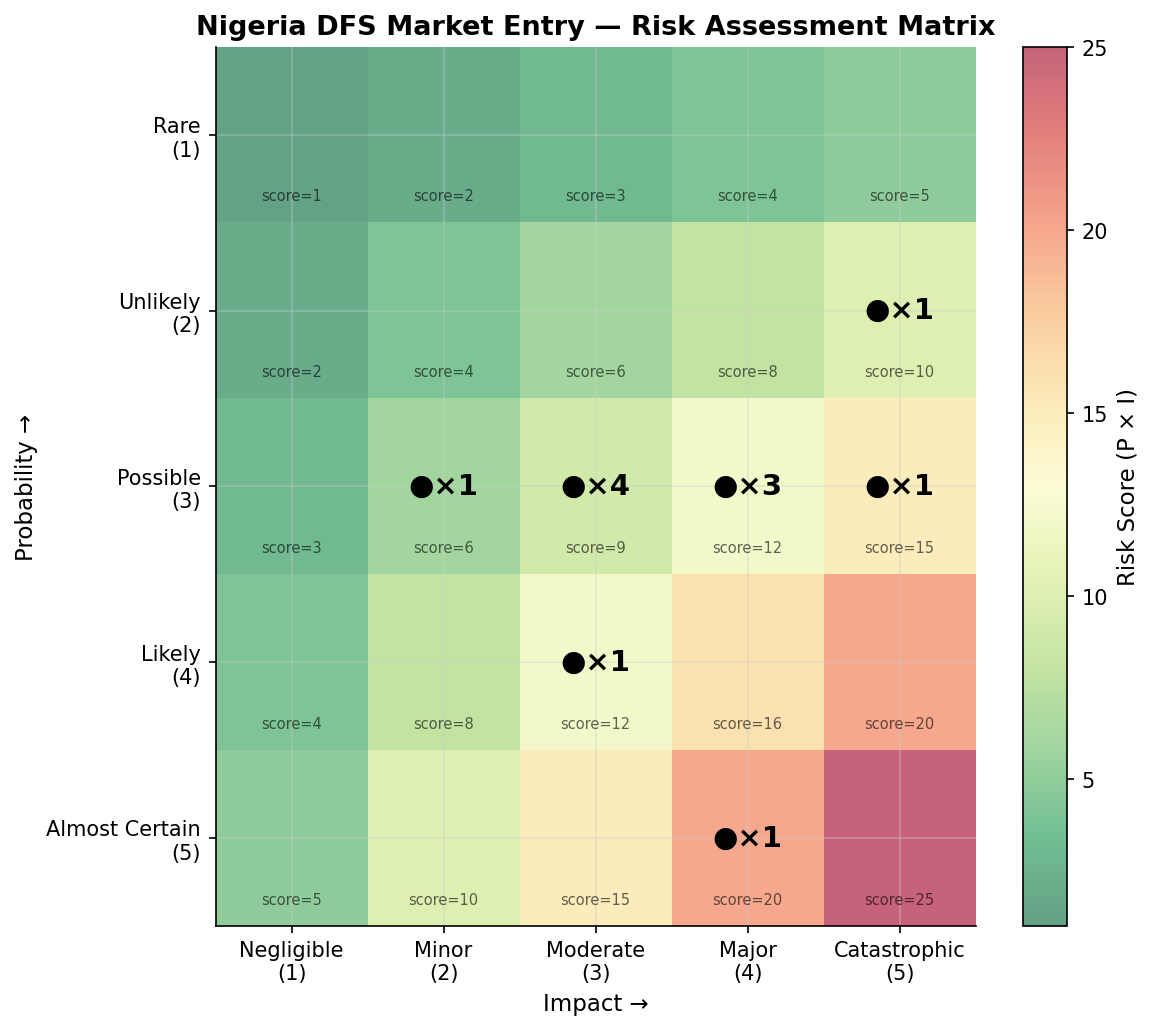


TOP 5 RISKS BY PRIORITY SCORE:
                                Risk  Risk Score Risk Tier                                                                                           Mitigation
     NGN Devaluation / FX Volatility          20  Critical           Revenue in NGN; funding in USD with natural hedge strategy; FX risk disclosed to investors
                CBN Licensing Denial          15  Critical Early pre-application engagement with CBN Innovation Lab; appoint CBN-experienced compliance officer
Inflation & Purchasing Power Erosion          12      High     Target essential payment services (utility bills, transport, remittances) which are less elastic
           Incumbent Telco Dominance          12      High          Partner with Tier-2 telcos; focus on underserved segments not yet captured by telco wallets
       Agent Network Quality Control          12      High           Tiered agent KYC; real-time monitoring dashboard; performance bonuses for compliant agents


In [3]:
fig = plot_risk_matrix(df_risks)
save_figure(fig, "fig14_risk_matrix_heatmap.png")
plt.show()

# Top 5 risks by score
print("\nTOP 5 RISKS BY PRIORITY SCORE:")
print(df_risks[['Risk', 'Risk Score', 'Risk Tier', 'Mitigation']].head(5).to_string(index=False))

## Strategic Opportunities

,Opportunity,Market Attractiveness,Comp. Advantage Pot.,Priority Score,Supporting Evidence,Recommended Timeline
0,BNPL / Nano-lending for SMEs,4,4,16,CBN reports 60% of SME credit demand is unmet ...,Q3 Year 1 – Q2 Year 2
1,Rural Agent Network Expansion,5,3,15,EFInA 2023: 26M adults remain financially excl...,Q1–Q4 Year 1
2,USSD / Feature-Phone Access,5,3,15,GSMA 2023: only 40% smartphone penetration in ...,Q1 Year 1 (must-have at launch)
3,Diaspora Remittance Corridor,4,3,12,World Bank: Nigeria received $20B in remittanc...,Q2 Year 2
4,Embedded Insurance (Micro-products),3,4,12,NAICOM: insurance penetration <1% of GDP — one...,Q4 Year 2


  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\therbo_consulting\nigeria_dfs_analysis\reports\figures\fig15_strategic_opportunity_matrix.png
  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\therbo_consulting\nigeria_dfs_analysis\reports\figures\fig15_strategic_opportunity_matrix.pdf


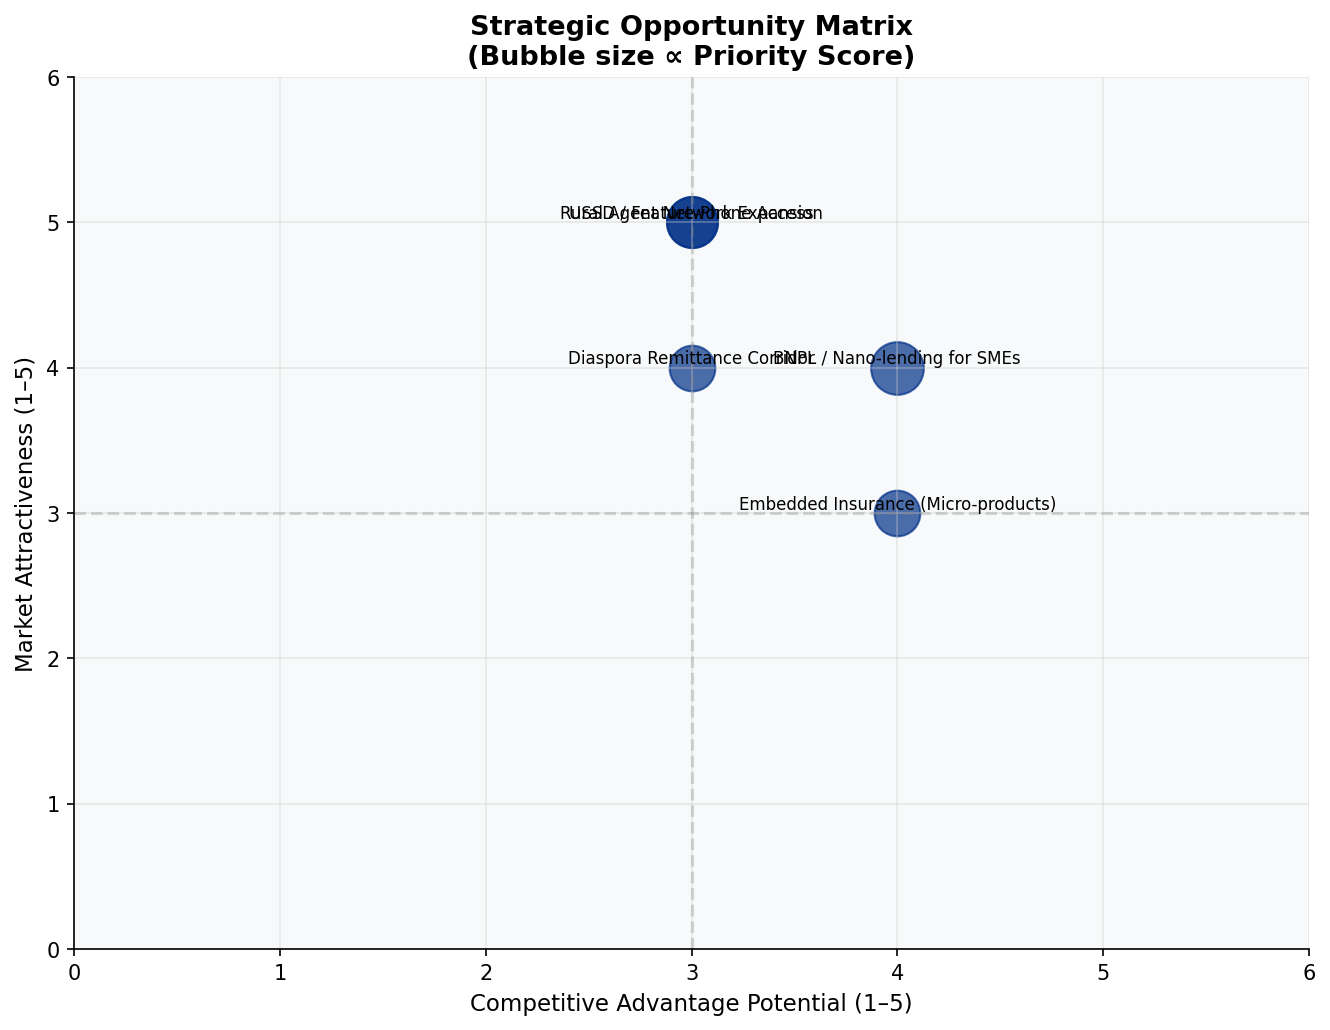

In [4]:
df_opps = strategic_opportunities()
display(df_opps[['Opportunity', 'Market Attractiveness', 'Comp. Advantage Pot.',
                   'Priority Score', 'Supporting Evidence', 'Recommended Timeline']])
df_opps.to_csv(tables_dir / "strategic_opportunities.csv", index=False)

# Opportunity matrix (2x2 positioning)
fig, ax = plt.subplots(figsize=(9, 7))
from src.config import BRAND_COLORS
for _, row in df_opps.iterrows():
    ax.scatter(row['Comp. Advantage Pot.'], row['Market Attractiveness'],
               s=row['Priority Score']*40, alpha=0.7, color=BRAND_COLORS['primary'])
    ax.annotate(row['Opportunity'],
                (row['Comp. Advantage Pot.'], row['Market Attractiveness']),
                fontsize=8, ha='center', va='bottom', wrap=True)

ax.set_xlabel("Competitive Advantage Potential (1–5)")
ax.set_ylabel("Market Attractiveness (1–5)")
ax.set_title("Strategic Opportunity Matrix\n(Bubble size ∝ Priority Score)")
ax.set_xlim(0, 6); ax.set_ylim(0, 6)
ax.axvline(3, color='grey', alpha=0.3, linestyle='--')
ax.axhline(3, color='grey', alpha=0.3, linestyle='--')
plt.tight_layout()
save_figure(fig, "fig15_strategic_opportunity_matrix.png")
plt.show()